<a href="https://colab.research.google.com/github/praveenm-web/NASSCOM/blob/main/Day4_U10_Feature_Engineering_Part1_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# === SETUP: load the provided data files (regenerate them if missing) ===
import os
import numpy as np
import pandas as pd

def build_datasets(csv_path='ecommerce_customers.csv',
                   xlsx_path='transactions.xlsx', seed=42, verbose=False):
    """Generate a realistic e-commerce customer + transactions dataset.

    Baked-in realism for EDA / feature engineering practice:
      - right-skewed monetary columns (total_spend) with a few 'whale' outliers
      - class imbalance in is_churned (~20-30%)
      - real signal: churn depends on recency, order count and support tickets
      - missing values in age / gender / city
      - a high-cardinality 'city' column (long tail of rare cities)
      - customers with zero orders (no last_order_date) -> dormant
    The Excel file is order-level and is CONSISTENT with the customer table
    (num_orders / total_spend / last_order_date are derived from it).
    """
    rng = np.random.default_rng(seed)
    N = 2500
    start = pd.Timestamp('2021-01-01')
    end = pd.Timestamp('2024-06-30')
    horizon = (end - start).days

    cust = np.array([f'CUST{i+1:05d}' for i in range(N)])
    signup_off = rng.integers(0, horizon - 60, N)
    signup = start + pd.to_timedelta(signup_off, unit='D')

    # order counts: overdispersed (gamma-poisson), some customers have zero
    lam = rng.gamma(2.0, 1.6, N)
    num_orders = rng.poisson(lam)

    # ---- order-level transactions (vectorised) ----
    counts = num_orders
    tot = int(counts.sum())
    cust_rep = np.repeat(cust, counts)
    signup_rep = np.repeat(signup_off, counts)
    span = np.maximum(horizon - signup_off, 1)
    span_rep = np.repeat(span, counts)
    off = (rng.random(tot) * span_rep).astype(int)
    tx_off = signup_rep + off
    tx_date = start + pd.to_timedelta(tx_off, unit='D')
    amount = rng.lognormal(3.2, 0.8, tot).round(2)        # right-skewed (~tens of currency)
    category = rng.choice(['Electronics', 'Fashion', 'Grocery', 'Home', 'Books'],
                          tot, p=[.20, .30, .25, .15, .10])
    tx = pd.DataFrame({'customer_id': cust_rep, 'order_date': tx_date,
                       'amount': amount, 'category': category}).sort_values(
        ['customer_id', 'order_date']).reset_index(drop=True)

    # ---- aggregate transactions -> customer level ----
    agg = tx.groupby('customer_id').agg(
        total_spend=('amount', 'sum'),
        first_order=('order_date', 'min'),
        last_order=('order_date', 'max'),
    ).reset_index()

    df = pd.DataFrame({'customer_id': cust, 'signup_date': signup,
                       'num_orders': num_orders})
    df = df.merge(agg, on='customer_id', how='left')
    df['total_spend'] = df['total_spend'].fillna(0).round(2)

    # ---- demographics & account attributes ----
    df['age'] = np.clip(rng.normal(38, 12, N), 18, 82).round().astype(int)
    df['gender'] = rng.choice(['M', 'F', 'Other'], N, p=[.48, .48, .04])

    majors = ['Mumbai', 'Delhi', 'Bengaluru', 'Hyderabad', 'Chennai', 'Pune', 'Kolkata']
    rare = ['Jaipur', 'Surat', 'Indore', 'Bhopal', 'Patna', 'Nagpur',
            'Kochi', 'Coimbatore', 'Visakhapatnam', 'Lucknow']
    pool = majors + rare
    w = np.array([.17, .15, .14, .12, .10, .08, .06] + [.013] * 10)
    w = w / w.sum()
    df['city'] = rng.choice(pool, N, p=w)

    df['plan'] = rng.choice(['Basic', 'Standard', 'Premium'], N, p=[.50, .35, .15])
    df['device'] = rng.choice(['Mobile', 'Desktop', 'Tablet'], N, p=[.60, .32, .08])
    df['payment_method'] = rng.choice(['Card', 'UPI', 'Wallet', 'NetBanking'],
                                      N, p=[.40, .35, .15, .10])
    df['support_tickets'] = rng.poisson(0.6, N)
    df['email_opt_in'] = rng.choice([0, 1], N, p=[.35, .65])

    # ---- churn target with real signal (recency / orders / tickets) ----
    last = pd.to_datetime(df['last_order'])
    days_since = (end - last).dt.days
    days_since_filled = days_since.fillna(horizon).to_numpy()
    z = (-2.75
         + 0.0019 * days_since_filled
         + 0.30 * df['support_tickets'].to_numpy()
         - 0.05 * df['num_orders'].to_numpy()
         + 0.70 * (df['num_orders'].to_numpy() == 0))
    p = 1 / (1 + np.exp(-z))
    df['is_churned'] = (rng.random(N) < p).astype(int)

    # ---- format dates as ISO strings (NaT -> <NA>) ----
    df = df.rename(columns={'first_order': 'first_order_date',
                            'last_order': 'last_order_date'})
    for c in ['signup_date', 'first_order_date', 'last_order_date']:
        df[c] = pd.to_datetime(df[c]).dt.date.astype('string')

    df = df[['customer_id', 'signup_date', 'first_order_date', 'last_order_date',
             'age', 'gender', 'city', 'plan', 'device', 'payment_method',
             'num_orders', 'total_spend', 'support_tickets', 'email_opt_in',
             'is_churned']]

    # ---- inject missing values AFTER computing the target ----
    def punch(col, frac):
        idx = rng.choice(N, int(frac * N), replace=False)
        df.loc[idx, col] = np.nan
    punch('age', 0.07)
    punch('gender', 0.04)
    punch('city', 0.02)

    # ---- write files ----
    df.to_csv(csv_path, index=False)
    tx_out = tx.copy()
    tx_out['order_date'] = pd.to_datetime(tx_out['order_date']).dt.date.astype('string')
    tx_out.to_excel(xlsx_path, index=False)

    if verbose:
        print('customers:', df.shape, '| transactions:', tx_out.shape)
        print('churn rate:', round(df["is_churned"].mean(), 3))
        print('total_spend skew:', round(df["total_spend"].skew(), 2))
        print('missing age:', int(df["age"].isna().sum()),
              '| missing city:', int(df["city"].isna().sum()))
        print('zero-order customers:', int((df["num_orders"] == 0).sum()))
        print('distinct cities:', df["city"].nunique())
    return df, tx_out

if not (os.path.exists('ecommerce_customers.csv') and os.path.exists('transactions.xlsx')):
    build_datasets()
    print('Generated dataset files.')
else:
    print('Found the provided dataset files.')

Found the provided dataset files.


In [4]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

SNAPSHOT = pd.Timestamp('2024-06-30')   # the day the data was pulled

cust = pd.read_csv('ecommerce_customers.csv',
                   parse_dates=['signup_date', 'first_order_date', 'last_order_date'])
tx = pd.read_excel('transactions.xlsx', parse_dates=['order_date'])
print('customers:', cust.shape, '| transactions:', tx.shape)
tx.head()

customers: (2500, 15) | transactions: (8152, 4)


,customer_id,order_date,amount,category
0,CUST00003,2023-05-22,39.17,Fashion
1,CUST00004,2022-07-02,2.74,Home
2,CUST00005,2022-09-18,26.27,Electronics
3,CUST00005,2023-04-07,33.48,Fashion
4,CUST00005,2023-08-04,56.41,Fashion


#1. Aggregate transactions → customer features (RFM)


In [5]:
# -----------------------------------------------------------
# 🔹 1A. ROLL UP ORDER-LEVEL ROWS TO ONE ROW PER CUSTOMER
# -----------------------------------------------------------
rfm = tx.groupby('customer_id').agg(
    frequency=('amount', 'size'),                 # F: how many orders
    monetary=('amount', 'sum'),                   # M: total spent
    avg_order_value=('amount', 'mean'),           # typical basket
    last_order=('order_date', 'max'),
    n_categories=('category', 'nunique'),         # breadth of interest
).reset_index()
# R: recency = days since last order, measured from the snapshot
rfm['recency_days'] = (SNAPSHOT - rfm['last_order']).dt.days
rfm[['customer_id', 'frequency', 'monetary', 'avg_order_value',
     'recency_days', 'n_categories']].head()

,customer_id,frequency,monetary,avg_order_value,recency_days,n_categories
0,CUST00003,1,39.17,39.17,405,1
1,CUST00004,1,2.74,2.74,729,1
2,CUST00005,4,133.80,33.45,15,3
3,CUST00006,1,23.36,23.36,45,1
4,CUST00007,2,73.70,36.85,684,2


In [6]:
# -----------------------------------------------------------
# 🔹 1B. MERGE THE NEW FEATURES BACK ONTO THE CUSTOMER TABLE
# -----------------------------------------------------------
df = cust.merge(rfm.drop(columns='last_order'), on='customer_id', how='left')
# customers with no transactions -> fill sensible defaults
df['frequency'] = df['frequency'].fillna(0)
df['monetary'] = df['monetary'].fillna(0)
df['n_categories'] = df['n_categories'].fillna(0)
# never ordered -> recency is 'infinitely' stale: cap at customer tenure
df['recency_days'] = df['recency_days'].fillna(9999)
print('Merged shape:', df.shape)
df[['customer_id', 'frequency', 'monetary', 'recency_days', 'is_churned']].head()

Merged shape: (2500, 20)


,customer_id,frequency,monetary,recency_days,is_churned
0,CUST00001,0.0,0.00,9999.0,0
1,CUST00002,0.0,0.00,9999.0,1
2,CUST00003,1.0,39.17,405.0,0
3,CUST00004,1.0,2.74,729.0,0
4,CUST00005,4.0,133.80,15.0,0


LAB EXERCISE 1 — Add an 'inter-order gap' feature


In [25]:
span_data = tx.groupby('customer_id')['order_date'].agg(
    min_order_date='min',
    max_order_date='max'
).reset_index()
span_data['active_span_days'] = (span_data['max_order_date'] - span_data['min_order_date']).dt.days

# Merge active_span_days onto df. Customers with no orders will have NaN here.
df = df.merge(span_data[['customer_id', 'active_span_days']], on='customer_id', how='left')

# Calculate avg_days_between_orders, guarding against division by zero for frequency <= 1
divisor = df['frequency'] - 1
# Replace 0 or -1 with NaN so division results in NaN, which we can then fill with 0.
divisor = divisor.replace({0: np.nan, -1: np.nan})
df['avg_days_between_orders'] = df['active_span_days'] / divisor

# Fill NaN values (from customers with 0 or 1 order, or no orders) with 0
df['avg_days_between_orders'] = df['avg_days_between_orders'].fillna(0)

# Display the head of the DataFrame with the new features
display(df[['customer_id', 'frequency', 'active_span_days', 'avg_days_between_orders']].head())

,customer_id,frequency,active_span_days,avg_days_between_orders
0,CUST00001,0.0,NaN,0.0
1,CUST00002,0.0,NaN,0.0
2,CUST00003,1.0,0.0,0.0
3,CUST00004,1.0,0.0,0.0
4,CUST00005,4.0,636.0,212.0


#2. Numeric transforms — fixing skew

skew before: 1.73
skew after : -1.12


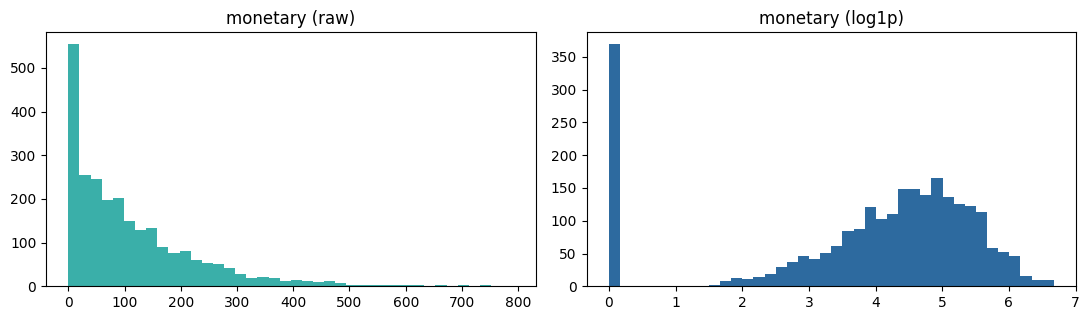

In [8]:
# -----------------------------------------------------------
# 🔹 2A. LOG-TRANSFORM A RIGHT-SKEWED COLUMN
# -----------------------------------------------------------
# EDA showed 'monetary' (total spend) is right-skewed. log1p compresses
# the long tail so big spenders don't dominate the model.
df['monetary_log'] = np.log1p(df['monetary'])   # log1p handles 0 safely
print('skew before:', round(df['monetary'].skew(), 2))
print('skew after :', round(df['monetary_log'].skew(), 2))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.3))
ax[0].hist(df['monetary'], bins=40, color='#3AAFA9'); ax[0].set_title('monetary (raw)')
ax[1].hist(df['monetary_log'], bins=40, color='#2D6A9F'); ax[1].set_title('monetary (log1p)')
plt.tight_layout(); plt.show()

LAB EXERCISE 2 — Tame another skewed feature


In [26]:
# 1. skew of avg_order_value (note: NaN for zero-order customers)
df['avg_order_value'] = df['avg_order_value'].fillna(0)
print(df['avg_order_value'].skew())

# 2. log-transform
df['aov_log'] = np.log1p(df['avg_order_value'])

# 3. print before/after skew
print(df['avg_order_value'].skew())
print(df['aov_log'].skew())



2.7229198578083276
2.7229198578083276
-1.4177629679940837


#3. Binning — continuous → groups

In [10]:
# -----------------------------------------------------------
# 🔹 3A. BUCKET AGE INTO LIFE-STAGE GROUPS
# -----------------------------------------------------------
df['age_group'] = pd.cut(df['age'], bins=[0, 25, 40, 60, 200],
                         labels=['<25', '25-39', '40-59', '60+'])
print(df['age_group'].value_counts(dropna=False))

age_group
25-39    1025
40-59     872
<25       355
NaN       175
60+        73
Name: count, dtype: int64


LAB EXERCISE 3 — Recency buckets


In [27]:
# 1. bucket recency_days  (tip: use bins=[-1, 30, 90, 100000])
df['recency_bucket'] = pd.cut(df['recency_days'], bins=[-1, 30, 90, 100000], labels=['active','lapsing','dormant'])

# 2. counts per bucket
print(df['recency_bucket'].value_counts())

# 3. pd.crosstab(bucket, df['is_churned'], normalize='index')
pd.crosstab(df['recency_bucket'], df['is_churned'], normalize='index')

recency_bucket
dormant    1507
lapsing     531
active      462
Name: count, dtype: int64


is_churned,0,1
recency_bucket,,
active,0.932900,0.067100
lapsing,0.947269,0.052731
dormant,0.763769,0.236231


#4. Ratios & interaction features

In [12]:
# -----------------------------------------------------------
# 🔹 4A. RATIOS THAT EXPOSE BEHAVIOUR  (mind divide-by-zero!)
# -----------------------------------------------------------
# tickets per order: a dissatisfaction signal, normalised by activity
df['tickets_per_order'] = df['support_tickets'] / df['frequency'].replace(0, np.nan)
df['tickets_per_order'] = df['tickets_per_order'].fillna(0)   # 0 orders -> 0

# spend per category: concentration of spend
df['spend_per_category'] = df['monetary'] / df['n_categories'].replace(0, np.nan)
df['spend_per_category'] = df['spend_per_category'].fillna(0)
print(df[['support_tickets', 'frequency', 'tickets_per_order',
          'monetary', 'n_categories', 'spend_per_category']].head())

   support_tickets  frequency  tickets_per_order  monetary  n_categories  \
0                2        0.0                0.0      0.00           0.0   
1                1        0.0                0.0      0.00           0.0   
2                1        1.0                1.0     39.17           1.0   
3                1        1.0                1.0      2.74           1.0   
4                0        4.0                0.0    133.80           3.0   

   spend_per_category  
0                0.00  
1                0.00  
2               39.17  
3                2.74  
4               44.60  


LAB EXERCISE 4 — Engagement ratio


In [28]:
# 1. tenure in months, then orders_per_month (guard divide-by-zero)
tenure_months = (SNAPSHOT - df['signup_date']).dt.days / 30
df['tenure_months'] = tenure_months
df['orders_per_month'] = df['frequency'] / tenure_months.replace(0, np.nan)

# 2. fill missing/infinite values with 0
df['orders_per_month'] = df['orders_per_month'].fillna(0)

# 2. replace inf/NaN with 0   (hint: .replace([np.inf,-np.inf], np.nan).fillna(0))
df['orders_per_month'] = df['orders_per_month'].replace([np.inf,-np.inf], np.nan).fillna(0)

# 3. top 5 by frequency
df.sort_values('frequency', ascending=False).head()

,customer_id,signup_date,first_order_date,last_order_date,age,gender,city,num_orders,total_spend,support_tickets,...,R_score,F_score,M_score,rfm_score,active_span_days,avg_days_between_orders,aov_log,recency_bucket,tenure_months,orders_per_month
237,CUST00238,2022-06-10,2022-06-13,2024-06-12,34.0,F,Delhi,19,584.23,1,...,4,4,4,12,730.0,40.555556,3.457860,active,25.033333,0.758988
812,CUST00813,2023-04-13,2023-04-13,2024-06-28,27.0,F,Delhi,18,791.37,3,...,4,4,4,12,442.0,26.000000,3.805884,active,14.800000,1.216216
562,CUST00563,2022-08-23,2022-11-10,2024-06-21,37.0,F,Delhi,17,727.37,1,...,4,4,4,12,589.0,36.812500,3.779325,active,22.566667,0.753323
1918,CUST01919,2022-07-04,2022-12-01,2024-05-11,44.0,F,Hyderabad,16,630.38,0,...,3,4,4,11,527.0,35.133333,3.698799,lapsing,24.233333,0.660248
1199,CUST01200,2023-01-25,2023-01-25,2024-06-01,40.0,F,Pune,16,628.48,0,...,4,4,4,12,493.0,32.866667,3.695855,active,17.400000,0.919540


#5. Datetime features

In [14]:
# -----------------------------------------------------------
# 🔹 5A. UNLOCK THE DATE COLUMNS
# -----------------------------------------------------------
df['tenure_days'] = (SNAPSHOT - df['signup_date']).dt.days   # how long a customer
df['signup_month'] = df['signup_date'].dt.month
df['signup_dow'] = df['signup_date'].dt.dayofweek            # 0=Mon
df['signup_is_weekend'] = (df['signup_dow'] >= 5).astype(int)
# cyclical encoding so Dec(12) and Jan(1) are 'close', not far apart
df['month_sin'] = np.sin(2 * np.pi * df['signup_month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['signup_month'] / 12)
df[['signup_date', 'tenure_days', 'signup_month',
    'signup_dow', 'signup_is_weekend', 'month_sin', 'month_cos']].head()

,signup_date,tenure_days,signup_month,signup_dow,signup_is_weekend,month_sin,month_cos
0,2021-04-19,1168,4,0,0,8.660254e-01,-5.000000e-01
1,2023-07-31,335,7,0,0,-5.000000e-01,-8.660254e-01
2,2023-03-07,481,3,1,0,1.000000e+00,6.123234e-17
3,2022-06-18,743,6,5,1,1.224647e-16,-1.000000e+00
4,2022-06-11,750,6,5,1,1.224647e-16,-1.000000e+00


LAB EXERCISE 5 — Days since first order


In [29]:
# 1. days from first_order_date to SNAPSHOT
df['days_since_first_order'] = (SNAPSHOT - df['first_order_date']).dt.days

# 2. fill NaT-derived NaN with 0
df['days_since_first_order'] = df['days_since_first_order'].fillna(0)

# 3. show a few rows
df[['first_order_date', 'days_since_first_order']].head()

,first_order_date,days_since_first_order
0,NaT,0.0
1,NaT,0.0
2,2023-05-22,405.0
3,2022-07-02,729.0
4,2022-09-18,651.0


#6. Encoding categorical features

In [16]:
# -----------------------------------------------------------
# 🔹 6A. ONE-HOT THE LOW-CARDINALITY COLUMNS
# -----------------------------------------------------------
df = pd.get_dummies(df, columns=['plan', 'device', 'payment_method'],
                    drop_first=False, dtype=int)
print('columns after one-hot:', df.shape[1])
print([c for c in df.columns if c.startswith(('plan_', 'device_'))])

columns after one-hot: 37
['plan_Basic', 'plan_Premium', 'plan_Standard', 'device_Desktop', 'device_Mobile', 'device_Tablet']


In [17]:
# -----------------------------------------------------------
# 🔹 6B. FREQUENCY-ENCODE THE HIGH-CARDINALITY 'city'
# -----------------------------------------------------------
# one-hot on 17 cities would add 17 sparse columns; frequency encoding
# keeps it to ONE numeric column = how common each city is.
freq = df['city'].value_counts(normalize=True)
df['city_freq'] = df['city'].map(freq).fillna(0)
print(df[['city', 'city_freq']].drop_duplicates().head(8))

          city  city_freq
0      Chennai   0.103265
1    Hyderabad   0.130612
2         Pune   0.082857
4       Mumbai   0.169796
5        Delhi   0.165306
10   Bengaluru   0.159184
13       Patna   0.013469
14  Coimbatore   0.016735


LAB EXERCISE 6 — Encode gender safely


In [30]:
# 1. fill missing gender with 'Unknown'
df['gender'] = df['gender'].fillna('Unknown')

# 2. one-hot encode gender
df = pd.get_dummies(df, columns=['gender'], drop_first=False, dtype=int)

# 3. show the new columns
print([c for c in df.columns if c.startswith(('gender_',))])

['gender_F', 'gender_M', 'gender_Other', 'gender_Unknown']


#7. Rare categories & high cardinality

In [19]:
# -----------------------------------------------------------
# 🔹 7A. BUCKET RARE CITIES INTO 'Other'
# -----------------------------------------------------------
top_cities = df['city'].value_counts().head(7).index   # keep the 7 biggest
df['city_grouped'] = df['city'].where(df['city'].isin(top_cities), 'Other')
print('before:', df['city'].nunique(), 'cities')
print('after :', df['city_grouped'].nunique(), 'categories')
print(df['city_grouped'].value_counts())

before: 17 cities
after : 8 categories
city_grouped
Mumbai       416
Delhi        405
Bengaluru    390
Other        373
Hyderabad    320
Chennai      253
Pune         203
Kolkata      140
Name: count, dtype: int64


LAB EXERCISE 7 — One-hot the grouped city


In [31]:
# 1. one-hot city_grouped
df = pd.get_dummies(df, columns=['city_grouped'], drop_first=False, dtype=int)

# 2. number of new city_grouped_* columns
print(df.shape[1])

# 3. Why group first: ...   (comment)
# high cardinality- The original data contains 17 district cities in one hot
# method it will creat 17 new columns. It increses the number of columns and
# computational complexity.

61


#8. Domain-driven features

In [21]:
# -----------------------------------------------------------
# 🔹 8A. ENCODE BUSINESS KNOWLEDGE AS FEATURES
# -----------------------------------------------------------
# a 'dormant' flag: no orders, or very stale
df['is_dormant'] = ((df['frequency'] == 0) | (df['recency_days'] > 180)).astype(int)
# a simple RFM score: rank each of R, F, M into 1-4 and combine
df['R_score'] = pd.qcut(-df['recency_days'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)
df['F_score'] = pd.qcut(df['frequency'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)
df['M_score'] = pd.qcut(df['monetary'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)
df['rfm_score'] = df['R_score'] + df['F_score'] + df['M_score']   # 3..12
print(df[['recency_days', 'frequency', 'monetary', 'rfm_score', 'is_dormant']].head())
print('\nMean churn by RFM score:')
print(df.groupby('rfm_score')['is_churned'].mean().round(2))

   recency_days  frequency  monetary  rfm_score  is_dormant
0        9999.0        0.0      0.00          3           1
1        9999.0        0.0      0.00          3           1
2         405.0        1.0     39.17          5           1
3         729.0        1.0      2.74          3           1
4          15.0        4.0    133.80         10           0

Mean churn by RFM score:
rfm_score
3     0.58
4     0.19
5     0.13
6     0.09
7     0.07
8     0.10
9     0.08
10    0.08
11    0.04
12    0.05
Name: is_churned, dtype: float64


LAB EXERCISE 8 — Invent a feature for the business


In [34]:
# 1. high_value flag (top 20% of monetary)
df['high_value'] = (df['monetary'] >= df['monetary'].quantile(0.8)).astype(int)

# 2. churn rate by high_value
print(df.groupby('high_value')['is_churned'].mean().round(2))

# 3. Another domain feature I'd add: 'Days since last support ticket'.
# This feature captures how recently a customer might have experienced an issue,
# which can be a strong predictor of churn if the issue is unresolved or recent.

high_value
0    0.19
1    0.05
Name: is_churned, dtype: float64


# 9. Assemble the feature matrix — and check for leakage


In [23]:
# -----------------------------------------------------------
# 🔹 9A. BUILD X (features) AND y (target)
# -----------------------------------------------------------
drop_cols = ['customer_id', 'signup_date', 'first_order_date', 'last_order_date',
             'city', 'gender', 'age_group', 'city_grouped', 'is_churned']
X = df.drop(columns=[c for c in drop_cols if c in df.columns])
X = X.select_dtypes(include='number')   # keep numeric features only
y = df['is_churned']
print('Feature matrix:', X.shape)
print('All numeric? ', X.select_dtypes(exclude='number').empty)
print('Any missing? ', int(X.isna().sum().sum()))
print('\nEngineered features include:')
print([c for c in X.columns if c in ('monetary_log','recency_days','rfm_score',
       'tickets_per_order','tenure_days','city_freq','is_dormant')])

Feature matrix: (2500, 35)
All numeric?  True
Any missing?  175

Engineered features include:
['recency_days', 'monetary_log', 'tickets_per_order', 'tenure_days', 'city_freq', 'is_dormant', 'rfm_score']


LAB EXERCISE 9 — Sanity-check & sniff for leakage


In [35]:
# 1. fill remaining missing values with the median
X = X.fillna(X.median())

# 2. correlation of each feature with y, sorted
#    hint: X.assign(churn=y).corr()['churn'].drop('churn').sort_values()
print(X.assign(churn=y).corr()['churn'].drop('churn').sort_values())

# 3. A feature that would be leakage: 'has_cancelled_subscription'.
# This feature would directly indicate if a customer has already churned (cancelled),
# meaning the information would only be available after the churn event has occurred.
# Including it would make the model appear to have perfect predictive power,
# but it wouldn't generalize to new, unchurned customers.

monetary_log                -0.474965
rfm_score                   -0.385565
n_categories                -0.355871
R_score                     -0.346636
M_score                     -0.339905
F_score                     -0.322597
spend_per_category          -0.289175
frequency                   -0.282144
num_orders                  -0.282144
avg_order_value             -0.281717
monetary                    -0.252546
total_spend                 -0.252546
tickets_per_order           -0.048281
payment_method_Wallet       -0.024611
signup_month                -0.018184
payment_method_NetBanking   -0.013934
age                         -0.010510
device_Desktop              -0.009811
plan_Premium                -0.009152
plan_Basic                  -0.008266
device_Tablet               -0.001560
signup_is_weekend            0.004310
payment_method_UPI           0.005824
month_cos                    0.006207
month_sin                    0.007953
device_Mobile                0.010228
email_opt_in